# Figure of subtype analysis 

In [ ]:
import scanpy as sc

import numpy as np
import pandas as pd

import os

In [ ]:
# rpy2 
os.environ['R_HOME'] = '/nobackup/peer/fdeckert/miniconda3/envs/r.4.1.0-FD20220623HSCT/lib/R'

In [ ]:
# sc.set_figure_params(figsize=(10, 10), dpi_save=1200, fontsize=18, frameon=False)

In [ ]:
os.chdir('/research/peer/fdeckert/FD20220623HSCT')

In [ ]:
# Load color 
import rpy2.robjects as robjects
color_load = robjects.r.source('plotting_global.R')
color = dict()
for i in range(len(color_load[0])):
    color[color_load[0].names[i]] = {key : color_load[0][i].rx2(key)[0] for key in color_load[0][i].names}

In [ ]:
# Set color function 
def set_color(categories, adata): 
    
    categories = [x for x in categories if x in list(adata.obs.columns)]
    
    for category in categories: 
        
        adata.obs[category] = pd.Series(adata.obs[category], dtype='category').cat.remove_unused_categories()
        
        keys = list(color[category].keys())
        keys = [x for x in keys if x in list(adata.obs[category])]        

        adata.obs[category] = adata.obs[category].cat.reorder_categories(keys)
        adata.uns[category+'_colors'] = np.array([color[category].get(key) for key in keys], dtype=object)
        
    return adata

# Files and parameter 

In [ ]:
# Seurat object 
pp_h5ad_file = 'data/object/pp_subset.h5ad'

# Import 

In [ ]:
adata = sc.read_h5ad(pp_h5ad_file)

# Marker genes

## Lymphocytes 

In [ ]:
cell_type_genes_dict = {
    
    r'$T_{conv}$': ['CD3D', 'CD4', 'CD8A', 'CD8B'], 
    r'Regulatory': ['FOXP3'], 
    r'Cytotoxic': ['KLRB1', 'GZMB', 'PRF1'], 
    r'NK': ['NCAM1', 'FCGR3A'], 
    r'$T_{inv}$': ['ZBTB16', 'SLC4A10', 'CEBPD'], 
    r'TRM': ['CD69', 'CREM'], 
    r'Naive': ['TCF7'], 
    r'Memory': ['CD44'], 
    r'Circulating': ['SELL', 'CCR7'], 
    r'Proliferating': ['MKI67']
    
}

In [ ]:
dp = sc.pl.dotplot(adata[adata.obs['domain_leiden_subset']=='lymphocyte'], cell_type_genes_dict, groupby='cell_type_leiden_subset', standard_scale='var', use_raw=False, dendrogram=False, return_fig=True, figsize=(10, 3))
dp = dp.add_totals().style(dot_edge_color='black', dot_edge_lw=0.5, cmap='Reds')
dp.savefig('result/annotation/sbusets/figure/lymphocyte_marker_genes.png', dpi=300, facecolor="white")

## Stuctural 

In [ ]:
cell_type_genes_dict = {
    
    r'Fibroblast': ['THY1'], 
    r'Reticular': ['MGP', 'FAP', 'MFAP5'], 
    r'Papillary': ['COL18A1', 'APCDD1', 'PTGDS'], 
    r'Dermal sheath': ['COL11A1', 'POSTN'], 
    r'Adermal Papilla': ['TNN', 'CRABP1'], 
    r'ECM': ['LGR5', 'MMP2', 'SPARC', 'TPM2', 'COMP', 'TNC'], 
    r'Activation': ['JUN', 'RARRES2'], 
    r'Inflammatroy': ['CXCL12', 'CXCL14', 'CXCL2', 'CXCL3', 'IL6'], 
    r'Basal': ['KRT5', 'KRT14'], 
    r'Suprabasal': ['KRT1', 'KRT10'], 
    r'Vascular': ['PECAM1', 'CD74'], 
    r'Lymphatic': ['LYVE1', 'CCL21'], 
    r'Perivascular': ['TAGLN', 'ACTA2'], 
    r'Chemotactic': ['CCL19', 'CCL26']
    
}

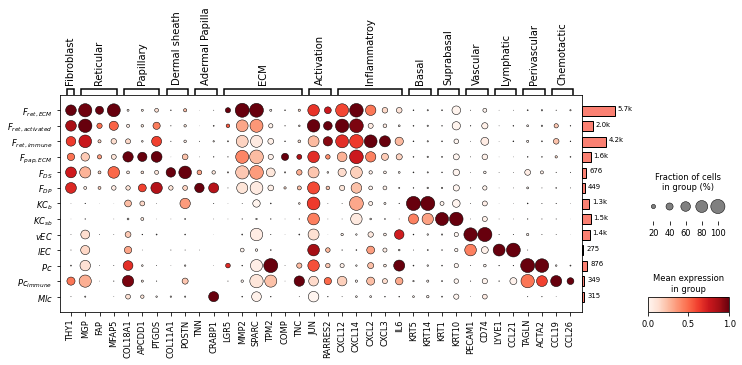

In [29]:
dp = sc.pl.dotplot(adata[adata.obs['domain_leiden_subset']=='structural'], cell_type_genes_dict, groupby='cell_type_leiden_subset', standard_scale='var', use_raw=False, dendrogram=False, return_fig=True, figsize=(12, 4))
dp = dp.add_totals().style(dot_edge_color='black', dot_edge_lw=0.5, cmap='Reds')
dp.savefig('result/annotation/sbusets/figure/structural_marker_genes.png', dpi=300, facecolor="white")